# Phase 1 — Exploratory Data Analysis
**Owner:** Saloni (Layer 1, 2) | Shiv (Layer 3, 4, 5)

**What is EDA?**
Before building any model, we need to understand the data.
EDA answers: what does the data look like, what problems does it have, and what patterns exist that we can use.

**Why do we do EDA first?**
If we skip EDA and jump straight to modelling, we will train on garbage data and get garbage results.
EDA tells us what to clean, what to engineer, and what to watch out for.

**Our dataset:**
- 76,020 customers, 369 anonymized features
- TARGET = 0 means satisfied, TARGET = 1 means dissatisfied
- All column names are in Spanish banking terminology
- There are no real NaN values — missing data is encoded as sentinel numbers like -999999

## Setup — Load Data

**Why this step?**
We load the data and immediately separate X (features) and y (target).
We keep y separate from X at all times — this is the most important rule in the project.
If y accidentally gets into X, the model will learn the answer and give fake good results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Kaggle data path — use this when running inside Kaggle
PATH = '/kaggle/input/competitions/santander-customer-satisfaction/'

train = pd.read_csv(PATH + 'train.csv')
test  = pd.read_csv(PATH + 'test.csv')

# Separate features from target immediately
# y travels separately throughout the entire project
X      = train.drop(['ID', 'TARGET'], axis=1)
y      = train['TARGET']
X_test = test.drop(['ID'], axis=1)

print('Data loaded successfully')
print(f'Train: {train.shape} | Test: {test.shape}')

Data loaded successfully
Train: (76020, 371) | Test: (75818, 370)


---
## Layer 1 — Shape and Health Check

**What we are doing:**
A quick 20-minute check to confirm the dataset is what we expect.
We check shape, data types, missing values, class balance, and column consistency.

**Why we do each check:**
- Shape: confirm we have the right number of rows and columns
- Dtypes: all features should be numeric — if any are objects we have a problem
- Nulls: confirm there are no real NaN values (missing data is hidden as sentinel numbers)
- Class balance: this tells us how severe our imbalance problem is
- Column match: train and test must have the same features or models will break

In [2]:
# ── Shape ─────────────────────────────────────────────────────────────
print('=== SHAPE ===')
print(f'Train: {X.shape[0]} rows, {X.shape[1]} features')
print(f'Test:  {X_test.shape[0]} rows, {X_test.shape[1]} features')

=== SHAPE ===
Train: 76020 rows, 369 features
Test:  75818 rows, 369 features


In [3]:
# ── Data types ────────────────────────────────────────────────────────
# Why: all 369 features should be numeric (float64 or int64)
# If any are 'object' type, they are strings and models cannot use them
print('=== DATA TYPES ===')
print(train.dtypes.value_counts())
print('\nAll numeric:', all(train.dtypes[col] in ['float64', 'int64'] 
                           for col in X.columns))

=== DATA TYPES ===
int64      260
float64    111
Name: count, dtype: int64

All numeric: True


In [4]:
# ── Missing values ────────────────────────────────────────────────────
# Why: we expect ZERO real NaN values
# Santander encoded missing data as sentinel numbers (-999999, 99, 117310.979)
# We will handle those later in cleaning
print('=== MISSING VALUES ===')
total_nulls = train.isnull().sum().sum()
print(f'Total NaN values: {total_nulls}')
print('Expected: 0')
print('Note: missing data is encoded as sentinel numbers, not NaN')

=== MISSING VALUES ===
Total NaN values: 0
Expected: 0
Note: missing data is encoded as sentinel numbers, not NaN


=== CLASS BALANCE ===
Satisfied   (0): 73,012 rows (96.0%)
Unsatisfied (1): 3,008 rows (4.0%)
Ratio: 24:1

IMPORTANT: Never use accuracy as a metric. Always use AUC-ROC.


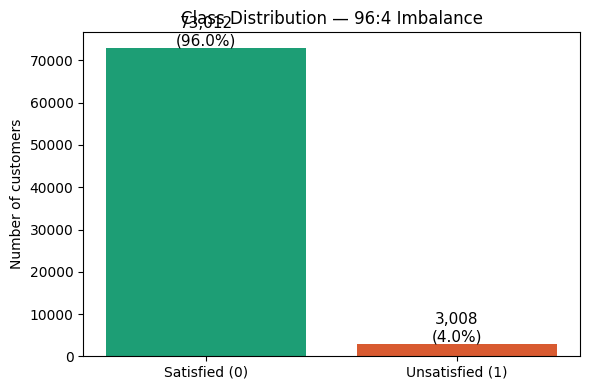

In [5]:
# ── Class balance ─────────────────────────────────────────────────────
# Why: this is our biggest problem
# 96% satisfied, 4% unsatisfied means a naive model that says
# 'everyone is satisfied' gets 96% accuracy but is completely useless
# This is why we use AUC-ROC not accuracy
print('=== CLASS BALANCE ===')
counts = y.value_counts()
proportions = y.value_counts(normalize=True)
print(f'Satisfied   (0): {counts[0]:,} rows ({proportions[0]*100:.1f}%)')
print(f'Unsatisfied (1): {counts[1]:,} rows ({proportions[1]*100:.1f}%)')
print(f'Ratio: {counts[0]//counts[1]}:1')
print('\nIMPORTANT: Never use accuracy as a metric. Always use AUC-ROC.')

# Plot
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.bar(['Satisfied (0)', 'Unsatisfied (1)'], counts.values, 
       color=['#1D9E75', '#D85A30'])
ax.set_title('Class Distribution — 96:4 Imbalance')
ax.set_ylabel('Number of customers')
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v:,}\n({proportions.values[i]*100:.1f}%)', 
            ha='center', fontsize=11)
plt.tight_layout()
plt.show()

In [6]:
# ── Column match ──────────────────────────────────────────────────────
# Why: train and test must have identical columns
# If train has columns that test does not, the model will break at prediction time
print('=== COLUMN MATCH ===')
diff = set(X.columns) - set(X_test.columns)
print(f'Columns in train but not test: {diff}')
print('Expected: empty set')
if not diff:
    print('All columns match')

=== COLUMN MATCH ===
Columns in train but not test: set()
Expected: empty set
All columns match


In [7]:
# ── Constant features ─────────────────────────────────────────────────
# Why: constant features (same value for every customer) carry zero information
# A model cannot learn anything from a column that never changes
# We flag them here and will drop them in cleaning
print('=== CONSTANT FEATURES ===')
const_cols = [c for c in X.columns if X[c].nunique() <= 1]
print(f'Count: {len(const_cols)} (expected: 34)')
print('\nThese will be dropped in Phase 2 cleaning:')
print(const_cols)

=== CONSTANT FEATURES ===
Count: 34 (expected: 34)

These will be dropped in Phase 2 cleaning:
['ind_var2_0', 'ind_var2', 'ind_var27_0', 'ind_var28_0', 'ind_var28', 'ind_var27', 'ind_var41', 'ind_var46_0', 'ind_var46', 'num_var27_0', 'num_var28_0', 'num_var28', 'num_var27', 'num_var41', 'num_var46_0', 'num_var46', 'saldo_var28', 'saldo_var27', 'saldo_var41', 'saldo_var46', 'imp_amort_var18_hace3', 'imp_amort_var34_hace3', 'imp_reemb_var13_hace3', 'imp_reemb_var33_hace3', 'imp_trasp_var17_out_hace3', 'imp_trasp_var33_out_hace3', 'num_var2_0_ult1', 'num_var2_ult1', 'num_reemb_var13_hace3', 'num_reemb_var33_hace3', 'num_trasp_var17_out_hace3', 'num_trasp_var33_out_hace3', 'saldo_var2_ult1', 'saldo_medio_var13_medio_hace3']


---
## Layer 2 — Feature Name Anatomy

**What we are doing:**
Decoding the column names to understand what type of data we have.
All 369 features are anonymized but their names follow a pattern from Spanish banking terminology.

**Why we do this:**
We cannot use domain knowledge because the columns are anonymized.
But the naming structure tells us: is this a balance? a count? a binary flag? from which time period?
This guides our feature engineering decisions later.

**The naming pattern:**
- `ind_` = indicator (binary 0/1 flag)
- `num_` = number/count
- `saldo_` = balance (monetary amount)
- `imp_` = importe (transaction amount)
- `delta_` = year-over-year change
- `_ult1` = last 1 month
- `_ult3` = last 3 months
- `_hace2` = 2 months ago
- `_hace3` = 3 months ago

In [8]:
# ── Group features by prefix ──────────────────────────────────────────
# Why: tells us what kinds of data we are working with
# Before touching any values, understand the structure
print('=== FEATURE GROUPS BY PREFIX ===')
prefixes = {'ind_': 'Binary indicators', 
            'num_': 'Counts', 
            'saldo_': 'Balances',
            'imp_': 'Transaction amounts', 
            'delta_': 'Year-over-year changes',
            'var_': 'Generic variables'}

for prefix, meaning in prefixes.items():
    cols = [c for c in X.columns if c.startswith(prefix)]
    print(f'{prefix:12s} ({meaning:25s}): {len(cols):3d} features')

=== FEATURE GROUPS BY PREFIX ===
ind_         (Binary indicators        ):  75 features
num_         (Counts                   ): 143 features
saldo_       (Balances                 ):  71 features
imp_         (Transaction amounts      ):  49 features
delta_       (Year-over-year changes   ):  26 features
var_         (Generic variables        ):   0 features


In [9]:
# ── Group features by time suffix ─────────────────────────────────────
# Why: tells us which features are time-windowed
# Features with _ult1 and _ult3 can be paired to create trend features later
# e.g. balance_last_month vs balance_last_3_months = is the customer's balance going up or down?
print('=== TEMPORAL FEATURES ===')
suffixes = {'_ult1': 'Last 1 month', 
            '_ult3': 'Last 3 months',
            '_hace2': '2 months ago', 
            '_hace3': '3 months ago',
            '_medio': 'Average'}

for suffix, meaning in suffixes.items():
    cols = [c for c in X.columns if suffix in c]
    print(f'{suffix:10s} ({meaning:20s}): {len(cols):3d} features')

# Find paired features (both _ult1 and _ult3 exist for same base)
print('\n=== PAIRED FEATURES (can create delta/ratio) ===')
ult1_bases = set(c.replace('_ult1', '') for c in X.columns if '_ult1' in c)
ult3_bases = set(c.replace('_ult3', '') for c in X.columns if '_ult3' in c)
pairs = ult1_bases & ult3_bases
print(f'Found {len(pairs)} paired bases:')
for p in sorted(pairs):
    print(f'  {p}_ult1 ↔ {p}_ult3')

=== TEMPORAL FEATURES ===
_ult1      (Last 1 month        ):  80 features
_ult3      (Last 3 months       ):  40 features
_hace2     (2 months ago        ):  15 features
_hace3     (3 months ago        ):  41 features
_medio     (Average             ):  46 features

=== PAIRED FEATURES (can create delta/ratio) ===
Found 27 paired bases:
  imp_op_var39_comer_ult1 ↔ imp_op_var39_comer_ult3
  imp_op_var39_efect_ult1 ↔ imp_op_var39_efect_ult3
  imp_op_var40_comer_ult1 ↔ imp_op_var40_comer_ult3
  imp_op_var40_efect_ult1 ↔ imp_op_var40_efect_ult3
  imp_op_var41_comer_ult1 ↔ imp_op_var41_comer_ult3
  imp_op_var41_efect_ult1 ↔ imp_op_var41_efect_ult3
  num_op_var39_ult1 ↔ num_op_var39_ult3
  num_op_var39_comer_ult1 ↔ num_op_var39_comer_ult3
  num_op_var39_efect_ult1 ↔ num_op_var39_efect_ult3
  num_op_var40_ult1 ↔ num_op_var40_ult3
  num_op_var40_comer_ult1 ↔ num_op_var40_comer_ult3
  num_op_var40_efect_ult1 ↔ num_op_var40_efect_ult3
  num_op_var41_ult1 ↔ num_op_var41_ult3
  num_op_var41_comer_

In [10]:
# ── Identify standalone root features ─────────────────────────────────
# Why: var3, var15, var38 are standalone features not derived from others
# These are the most important individual features to investigate deeply
# var15 = customer age, var38 = mortgage value, var3 = nationality
print('=== STANDALONE VAR FEATURES (highest priority) ===')
standalone = ['var3', 'var15', 'var36', 'var38']
for v in standalone:
    if v in X.columns:
        print(f'{v}: {X[v].nunique()} unique values, '
              f'min={X[v].min():.1f}, max={X[v].max():.1f}')

print('\nThese will be deep-dived in Layer 3')

=== STANDALONE VAR FEATURES (highest priority) ===
var3: 208 unique values, min=-999999.0, max=238.0
var15: 100 unique values, min=5.0, max=105.0
var36: 5 unique values, min=0.0, max=99.0
var38: 57736 unique values, min=5163.8, max=22034738.8

These will be deep-dived in Layer 3


In [11]:
# ── Delta columns check ───────────────────────────────────────────────
# Why: delta columns have 1e10 as a sentinel value for missing
# This means the column is mostly a placeholder, not real data
# We will drop all 26 delta columns in cleaning
print('=== DELTA COLUMNS (will be dropped) ===')
delta_cols = [c for c in X.columns if c.startswith('delta_')]
print(f'Count: {len(delta_cols)}')

# Check for 1e10 sentinel
delta_sentinel = [(c, (X[c] == 1e10).sum()) for c in delta_cols[:5]]
print('\nSample of 1e10 sentinel counts (first 5 delta cols):')
for col, count in delta_sentinel:
    print(f'  {col}: {count} rows with 1e10 value')
print('\nDecision: drop all delta columns — dominated by sentinel values')

=== DELTA COLUMNS (will be dropped) ===
Count: 26

Sample of 1e10 sentinel counts (first 5 delta cols):
  delta_imp_amort_var18_1y3: 0 rows with 1e10 value
  delta_imp_amort_var34_1y3: 0 rows with 1e10 value
  delta_imp_aport_var13_1y3: 0 rows with 1e10 value
  delta_imp_aport_var17_1y3: 0 rows with 1e10 value
  delta_imp_aport_var33_1y3: 0 rows with 1e10 value

Decision: drop all delta columns — dominated by sentinel values


---
## Layer 3 — Univariate Analysis

**What we are doing:**
Looking at individual features one by one to find patterns.

**Why:**
This is where we find the key rules that will give us free AUC points.
For example: no customer under age 23 is dissatisfied — we can use this as a hard rule in post-processing.

**Note:** Layers 3, 4, 5 are primarily Shiv's responsibility.
Saloni does sparsity map here as it feeds directly into feature selection on Day 5.

=== SPARSITY MAP ===
Features with >95% zeros: 283
Features with >80% zeros: 333
Features with >50% zeros: 340


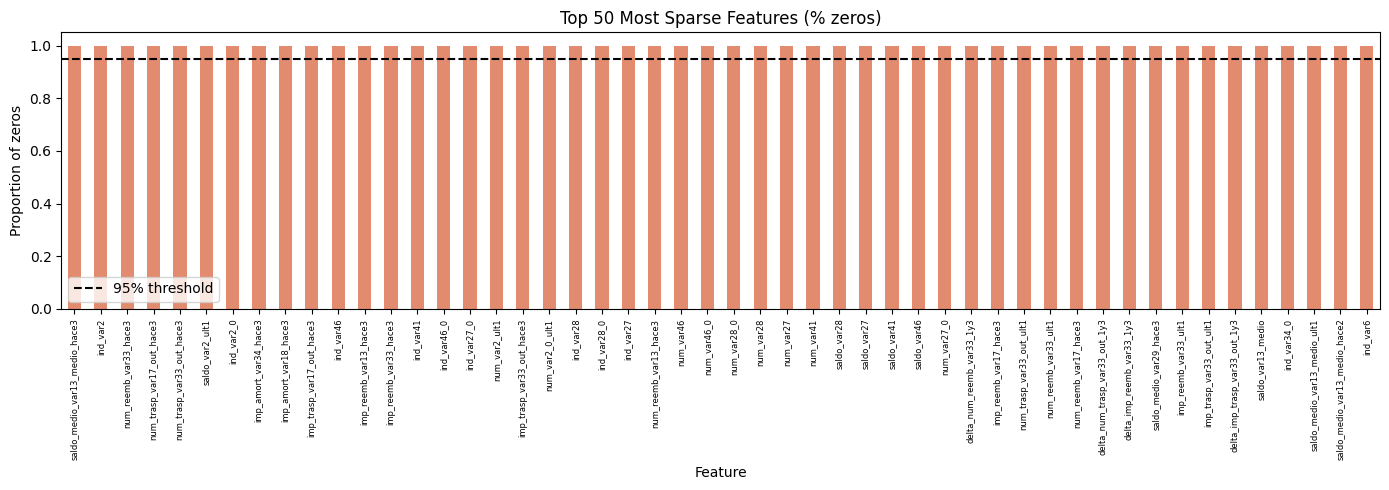


Insight: Most features are mostly zeros.
This is why count_zeros per row is our most powerful engineered feature.
Dissatisfied customers tend to have MORE zeros (less activity).


In [12]:
# ── Sparsity map ──────────────────────────────────────────────────────
# Why: sparsity = how many zeros a feature has
# Features with 95%+ zeros are almost always zero — they carry little signal
# Highly sparse features that also show no correlation with TARGET will be dropped
# count_zeros (a feature we will engineer) is powerful BECAUSE of this sparsity
print('=== SPARSITY MAP ===')
sparsity = (X == 0).mean().sort_values(ascending=False)
print(f'Features with >95% zeros: {(sparsity > 0.95).sum()}')
print(f'Features with >80% zeros: {(sparsity > 0.80).sum()}')
print(f'Features with >50% zeros: {(sparsity > 0.50).sum()}')

# Plot top 50 most sparse features
fig, ax = plt.subplots(figsize=(14, 5))
sparsity.head(50).plot(kind='bar', ax=ax, color='#D85A30', alpha=0.7)
ax.axhline(0.95, color='black', linestyle='--', label='95% threshold')
ax.set_title('Top 50 Most Sparse Features (% zeros)')
ax.set_ylabel('Proportion of zeros')
ax.set_xlabel('Feature')
ax.legend()
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.show()

print('\nInsight: Most features are mostly zeros.')
print('This is why count_zeros per row is our most powerful engineered feature.')
print('Dissatisfied customers tend to have MORE zeros (less activity).')

=== VAR15 — CUSTOMER AGE ===
Range: 5 to 105
Customers under 23: 1,212
Unsatisfied AND under 23: 0
CONFIRMED RULE: No unsatisfied customer under age 23


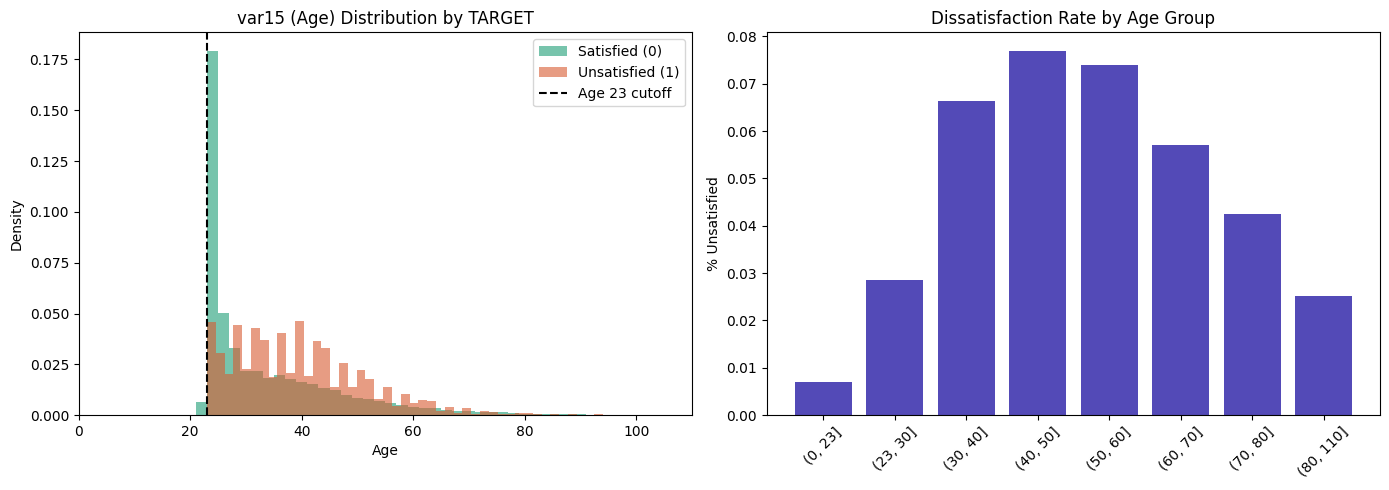

In [13]:
# ── var15 deep dive (customer age) ────────────────────────────────────
# Why: var15 is the most important individual feature (26.8% XGB gain)
# EDA confirmed: zero unsatisfied customers under age 23
# This gives us a FREE rule: if age < 23, set prediction to 0 at submission time
print('=== VAR15 — CUSTOMER AGE ===')
print(f'Range: {X["var15"].min()} to {X["var15"].max()}')
print(f'Customers under 23: {(X["var15"] < 23).sum():,}')
print(f'Unsatisfied AND under 23: {((X["var15"] < 23) & (y == 1)).sum()}')
print('CONFIRMED RULE: No unsatisfied customer under age 23')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by TARGET
axes[0].hist(X['var15'][y==0], bins=50, alpha=0.6, color='#1D9E75', 
             label='Satisfied (0)', density=True)
axes[0].hist(X['var15'][y==1], bins=50, alpha=0.6, color='#D85A30', 
             label='Unsatisfied (1)', density=True)
axes[0].axvline(23, color='black', linestyle='--', label='Age 23 cutoff')
axes[0].set_title('var15 (Age) Distribution by TARGET')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].legend()

# Dissatisfaction rate by age group
age_bins = pd.cut(X['var15'], bins=[0,23,30,40,50,60,70,80,110])
rate = y.groupby(age_bins).mean()
axes[1].bar(range(len(rate)), rate.values, color='#534AB7')
axes[1].set_xticks(range(len(rate)))
axes[1].set_xticklabels([str(b) for b in rate.index], rotation=45)
axes[1].set_title('Dissatisfaction Rate by Age Group')
axes[1].set_ylabel('% Unsatisfied')

plt.tight_layout()
plt.show()

=== VAR38 — MORTGAGE / NET WORTH ===
Sentinel value count: 14,868 rows
That is 19.6% of data
Dissatisfied among sentinel rows: 4.1%
Dissatisfied among non-sentinel rows: 3.9%


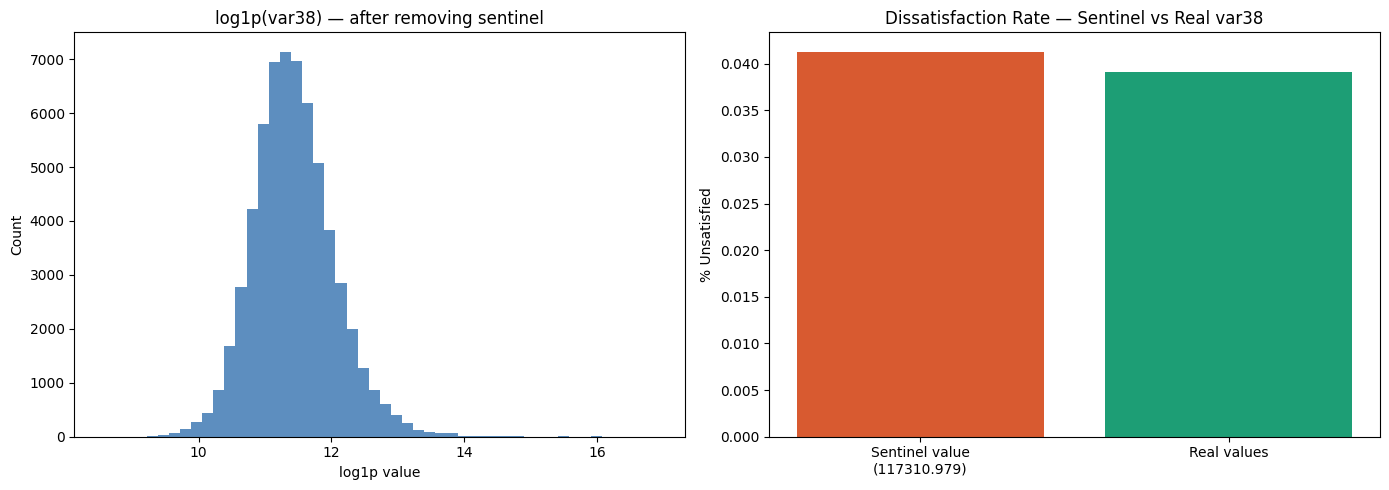


Decision: replace sentinel with NaN then median, create var38_was_mode flag


In [14]:
# ── var38 deep dive (mortgage / net worth) ────────────────────────────
# Why: var38 is the 3rd most important feature
# BUT it contains a sentinel value: 117310.979016494 appears 14,868 times
# This is NOT a real mortgage value — it is imputed missing data
# We need to flag these rows and replace the value before modelling
VAR38_SENTINEL = 117310.979016494

print('=== VAR38 — MORTGAGE / NET WORTH ===')
print(f'Sentinel value count: {(X["var38"] == VAR38_SENTINEL).sum():,} rows')
print(f'That is {(X["var38"] == VAR38_SENTINEL).mean()*100:.1f}% of data')
print(f'Dissatisfied among sentinel rows: '
      f'{y[X["var38"] == VAR38_SENTINEL].mean()*100:.1f}%')
print(f'Dissatisfied among non-sentinel rows: '
      f'{y[X["var38"] != VAR38_SENTINEL].mean()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution without sentinel
var38_clean = X['var38'][X['var38'] != VAR38_SENTINEL]
axes[0].hist(np.log1p(var38_clean), bins=50, color='#185FA5', alpha=0.7)
axes[0].set_title('log1p(var38) — after removing sentinel')
axes[0].set_xlabel('log1p value')
axes[0].set_ylabel('Count')

# Sentinel vs non-sentinel dissatisfaction rate
axes[1].bar(['Sentinel value\n(117310.979)', 'Real values'], 
            [y[X['var38'] == VAR38_SENTINEL].mean(),
             y[X['var38'] != VAR38_SENTINEL].mean()],
            color=['#D85A30', '#1D9E75'])
axes[1].set_title('Dissatisfaction Rate — Sentinel vs Real var38')
axes[1].set_ylabel('% Unsatisfied')

plt.tight_layout()
plt.show()

print('\nDecision: replace sentinel with NaN then median, create var38_was_mode flag')

In [15]:
# ── var3 sentinel check (nationality) ────────────────────────────────
# Why: var3 has -999999 as a sentinel for unknown nationality
# We need to flag these and replace before modelling
print('=== VAR3 — NATIONALITY ===')
print(f'Unique values: {X["var3"].nunique()}')
print(f'Sentinel -999999: {(X["var3"] == -999999).sum()} rows')
print(f'Most common value (mode): {X["var3"].mode()[0]}')
print('\nDecision: replace -999999 with mode, create var3_missing flag')

# var36 check
print('\n=== VAR36 ===')
print(f'Unique values: {sorted(X["var36"].unique())}')
print(f'Value 99 count: {(X["var36"] == 99).sum():,} rows'
      f' ({(X["var36"] == 99).mean()*100:.1f}% of data)')
print('Note: 99 appears in 40% of data — too frequent to be a rare sentinel')
print('Decision: keep 99 as its own category, create var36_is_99 flag')

=== VAR3 — NATIONALITY ===
Unique values: 208
Sentinel -999999: 116 rows
Most common value (mode): 2

Decision: replace -999999 with mode, create var3_missing flag

=== VAR36 ===
Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(99)]
Value 99 count: 30,064 rows (39.5% of data)
Note: 99 appears in 40% of data — too frequent to be a rare sentinel
Decision: keep 99 as its own category, create var36_is_99 flag


---
## Summary of Key Findings

**What we found and what we will do about it:**

In [16]:
print('=== KEY FINDINGS SUMMARY ===')
print()
print('DATASET:')
print(f'  76,020 training rows, 369 features')
print(f'  96.04% satisfied, 3.96% unsatisfied — severe imbalance')
print(f'  Metric: AUC-ROC only, never accuracy')
print()
print('PROBLEMS TO FIX IN CLEANING:')
print(f'  34 constant columns — zero information, will drop')
print(f'  26 delta columns — 1e10 sentinel, will drop')
print(f'  var3 == -999999: 116 rows — replace with mode, add flag')
print(f'  var36 == 99: 30,064 rows — keep as category, add flag')
print(f'  var38 == 117310.979: 14,868 rows — replace with median, add flag')
print()
print('RULES CONFIRMED FROM EDA (free AUC points):')
print(f'  var15 < 23: {((X["var15"] < 23) & (y == 1)).sum()} unsatisfied — ZERO')
print(f'  Post-processing rule: set prediction = 0 where var15 < 23')
print()
print('FEATURES TO ENGINEER (Phase 3):')
print('  count_zeros per row — most powerful engineered feature')
print('  is_young (var15 < 23), is_elderly (var15 > 80)')
print('  saldo_var30_zero, saldo5_ult3_zero')
print('  log transforms on saldo_ and imp_ columns')
print('  temporal deltas (ult1 - ult3 pairs)')

=== KEY FINDINGS SUMMARY ===

DATASET:
  76,020 training rows, 369 features
  96.04% satisfied, 3.96% unsatisfied — severe imbalance
  Metric: AUC-ROC only, never accuracy

PROBLEMS TO FIX IN CLEANING:
  34 constant columns — zero information, will drop
  26 delta columns — 1e10 sentinel, will drop
  var3 == -999999: 116 rows — replace with mode, add flag
  var36 == 99: 30,064 rows — keep as category, add flag
  var38 == 117310.979: 14,868 rows — replace with median, add flag

RULES CONFIRMED FROM EDA (free AUC points):
  var15 < 23: 0 unsatisfied — ZERO
  Post-processing rule: set prediction = 0 where var15 < 23

FEATURES TO ENGINEER (Phase 3):
  count_zeros per row — most powerful engineered feature
  is_young (var15 < 23), is_elderly (var15 > 80)
  saldo_var30_zero, saldo5_ult3_zero
  log transforms on saldo_ and imp_ columns
  temporal deltas (ult1 - ult3 pairs)


---
## Next Steps

- **Shiv** continues with Layer 3 (sparsity), Layer 4 (correlation with TARGET, mutual info), Layer 5 (multivariate)
- **Parul** starts cleaning pipeline in notebook 02
- **Saloni** continues with Layer 4 on Day 3 — correlation ranking and top 50 feature list
- **Team Sync 2** on Day 3 evening — everyone presents EDA findings